In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import brier_score
from scipy.interpolate import interp1d
from sklearn.inspection import permutation_importance
from sksurv.metrics import concordance_index_censored



In [29]:
#Load the data 

train_df = pd.read_csv("../data/train.csv")
train_df = train_df.drop("event_id", axis=1)


test_df = pd.read_csv("../data/test.csv")
test_event_id = test_df["event_id"].copy()

meta_df = pd.read_csv("../data/metaData.csv")

submission = pd.read_csv("../data/sample_submission.csv")

In [30]:
train_df.head()

,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,0.03545,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,0.00000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,0.00000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,0.00000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


In [31]:
# Check dataset dimensions
print(f"Number of training samples: {train_df.shape[0]}")
print(f"Number of features: {train_df.shape[1]}")
print(f"Number of test samples: {test_df.shape[0]}")

Number of training samples: 221
Number of features: 36
Number of test samples: 95


In [32]:
# Calculate some basic statistics
n_hits = int(train_df['event'].sum())
n_censored = len(train_df) - n_hits
hit_times = train_df.loc[train_df['event'], 'time_to_hit_hours']

# Print a summary

print(f"Training set:   {train_df.shape[0]} fires with {train_df.shape[1]} columns")
print(f"Test set:       {test_df.shape[0]} fires with {test_df.shape[1]} columns")
print()
print("Target distribution in training data:")
print(f"  Fires that HIT:        {n_hits} ({n_hits/len(train_df)*100:.1f}%)")
print(f"  Censored (no hit):     {n_censored} ({n_censored/len(train_df)*100:.1f}%)")
print()
print("Time to hit (for fires that hit):")
print(f"  Average: {hit_times.mean():.1f} hours")
print(f"  Median:  {hit_times.median():.1f} hours")
print(f"  Fastest: {hit_times.min():.2f} hours")
print(f"  Slowest: {hit_times.max():.1f} hours")
print()
print(f"Missing values: {train_df.isnull().sum().sum()}")
print(f"Unique values per column:")
print(train_df.nunique())



Training set:   221 fires with 36 columns
Test set:       95 fires with 35 columns

Target distribution in training data:
  Fires that HIT:        69 (31.2%)
  Censored (no hit):     152 (68.8%)

Time to hit (for fires that hit):
  Average: 19.9 hours
  Median:  18.9 hours
  Fastest: 18.89 hours
  Slowest: 22.0 hours

Missing values: 0
Unique values per column:
num_perimeters_0_5h              12
dt_first_last_0_5h               62
low_temporal_resolution_0_5h      2
area_first_ha                   221
area_growth_abs_0_5h             26
area_growth_rel_0_5h             26
area_growth_rate_ha_per_h        26
log1p_area_first                221
log1p_growth                     25
log_area_ratio_0_5h              26
relative_growth_0_5h             26
radial_growth_m                  26
radial_growth_rate_m_per_h       26
centroid_displacement_m          26
centroid_speed_m_per_h           26
spread_bearing_deg               26
spread_bearing_sin               26
spread_bearing_cos      

In [33]:
#Preprocess the data


X = train_df.drop(["time_to_hit_hours", "event"], axis=1)
y = train_df[["event", "time_to_hit_hours"]]

X_test = test_df.copy()


# try this later to see if performance improves 
#one-hot encode the event_start_month column and drop the original column
X = pd.get_dummies(X, columns=["event_start_month"], drop_first=True)
#get rid of potentially redundant features
X = X.drop(["area_first_ha", "area_growth_abs_0_5h"], axis=1)


In [34]:
FIRE_COLORS = ['#ff6b35', '#ff3333', '#ffcc02', '#ff8c42']
HIT_COLOR = '#ff4444'     
MISS_COLOR = '#58a6ff'     
SAFE_COLOR = '#3fb950'     

BACKGROUND = '#0f1117'
CARD_BG = '#161b22'
TEXT_COLOR = '#e6edf3'
MUTED_COLOR = '#7d8590'
GRID_COLOR = '#21262d'

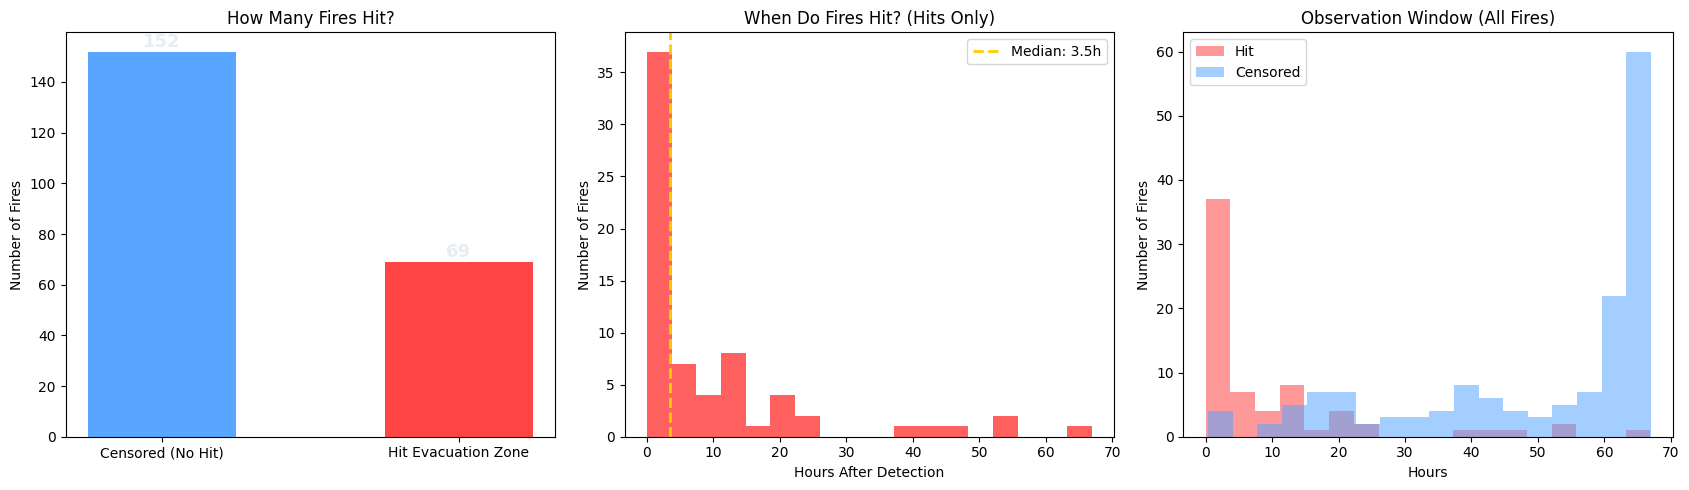

Key Insight: Most fires that hit do so within the first 20 hours!
  50% of hits occur within 3.5 hours
  75% of hits occur within 14.3 hours


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Chart 1: Event distribution (hit vs censored)
counts = train_df['event'].value_counts().sort_index()
bars = axes[0].bar(
    ['Censored (No Hit)', 'Hit Evacuation Zone'],
    counts.values,
    color=[MISS_COLOR, HIT_COLOR],
    edgecolor='none',
    width=0.5
)

# Add count labels on bars
for bar, count in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        count + 2,
        str(count),
        ha='center',
        color=TEXT_COLOR,
        fontweight='bold',
        fontsize=13
    )

axes[0].set_title('How Many Fires Hit?')
axes[0].set_ylabel('Number of Fires')

# Chart 2: Time to hit distribution (hits only)
hits = train_df[train_df['event'] == 1]['time_to_hit_hours']
axes[1].hist(hits, bins=18, color=HIT_COLOR, alpha=0.85, edgecolor='none')
axes[1].axvline(
    hits.median(),
    color=FIRE_COLORS[2],
    ls='--',
    lw=2,
    label=f'Median: {hits.median():.1f}h'
)
axes[1].set_title('When Do Fires Hit? (Hits Only)')
axes[1].set_xlabel('Hours After Detection')
axes[1].set_ylabel('Number of Fires')
axes[1].legend()


# Chart 3: Observation window for all fires
for label, color, mask in [
    ('Hit', HIT_COLOR, train_df['event'] == 1),
    ('Censored', MISS_COLOR, train_df['event'] == 0)
]:
    axes[2].hist(
        train_df.loc[mask, 'time_to_hit_hours'],
        bins=18,
        alpha=0.55,
        color=color,
        label=label,
        edgecolor='none'
    )

axes[2].set_title('Observation Window (All Fires)')
axes[2].set_xlabel('Hours')
axes[2].set_ylabel('Number of Fires')
axes[2].legend()

plt.tight_layout()
plt.show()

print("Key Insight: Most fires that hit do so within the first 20 hours")
print(f"  50% of hits occur within {hits.median():.1f} hours")
print(f"  75% of hits occur within {hits.quantile(0.75):.1f} hours")

In [36]:
#get all features
feature_cols= [col for col in train_df.columns if col not in ["event","time_to_hit_hours"]]
print("Features:", feature_cols)

#caclculte correlation with target
corr_with_event = train_df[feature_cols].corrwith(train_df['event']).abs()
corr_with_time = train_df[feature_cols].corrwith(train_df['time_to_hit_hours']).abs()

print("Top features correlated with event:")
print(corr_with_event.sort_values(ascending=False).head(10) )
print()
print("Top features correlated with time to hit:")
print(corr_with_time.sort_values(ascending=False).head(10) )

Features: ['num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos', 'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'closing_speed_abs_m_per_h', 'projected_advance_m', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'alignment_cos', 'alignment_abs', 'cross_track_component', 'along_track_speed', 'event_start_hour', 'event_start_dayofweek', 'event_start_month']
Top features correlated with event:
dist_min_ci_0_5h                0.481379
low_temporal_resolution_0_5h    0.379117
num_perimeters_0_5h             0.370501
dt_first_last_0_5h              0.352954
alignment_abs   

In [37]:
def make_features(df: pd.DataFrame) -> pd.DataFrame:
    base = df[[
        "dist_min_ci_0_5h",
        "alignment_abs",
        "closing_speed_m_per_h",
        "dt_first_last_0_5h",
        "num_perimeters_0_5h",
        "spread_bearing_cos",
    ]].copy()

    base["inv_dist_min"] = 1 / (base["dist_min_ci_0_5h"] + 1e-6)
    base["threat_projection"] = base["alignment_abs"] * base["inv_dist_min"]
    base["time_to_collision_est"] = base["dist_min_ci_0_5h"] / (base["closing_speed_m_per_h"] + 1e-6)
    base["directed_growth"] = base["time_to_collision_est"] * base["threat_projection"]
    base["signal_confidence"] = (
        base["num_perimeters_0_5h"] * base["dt_first_last_0_5h"] *
        (1 - (base["spread_bearing_cos"] > 0.5).astype(int))
    )

    return base

In [38]:
# Prepare data for modeling ===#

X = make_features(train_df)
X_test = make_features(test_df)

y = np.array(
    list(zip(train_df["event"].astype(bool), train_df["time_to_hit_hours"].astype(float))),
    dtype=[("event", bool), ("time", float)]
)


# Split the data into training and validation sets
X_train, X_val, y_train_event, y_val_event, y_train_time, y_val_time = train_test_split(
    X, train_df['event'], train_df['time_to_hit_hours'], test_size=0.2, random_state=42
)

In [39]:

# Create structured array for survival data
y_train = np.array(list(zip(y_train_event, y_train_time)),
                   dtype=[('event', bool), ('time', float)])
y_val = np.array(list(zip(y_val_event, y_val_time)),
                 dtype=[('event', bool), ('time', float)])

rsf = RandomSurvivalForest(
    n_estimators=2000,
    max_depth=None,
    min_samples_split=20,
    min_samples_leaf=3,
    max_features="log2",
    n_jobs=-1,
    random_state=42
)

rsf.fit(X_train, y_train)

RandomSurvivalForest(max_features='log2', min_samples_split=20,
                     n_estimators=2000, n_jobs=-1, random_state=42)

In [40]:
# 1. Gradient Boosting Survival stacking
from sksurv.ensemble import GradientBoostingSurvivalAnalysis

# Fit GBSA on same features
gbsa = GradientBoostingSurvivalAnalysis(
    n_estimators=700,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
# y_train is structured array
gbsa.fit(X_train, y_train)

# 2. Get survival curves from GBSA
surv_probs_gbsa = gbsa.predict_survival_function(X_test, return_array=True)

# 3. Combine RSF + GBSA 
surv_probs_rsf = rsf.predict_survival_function(X_test, return_array=True)

# Ensemble by averaging survival probabilities
ensemble_surv = (surv_probs_rsf + surv_probs_gbsa) / 2

# Overwrite surv_probs_test for downstream horizon extraction 
surv_probs_test = ensemble_surv

In [41]:
from sksurv.linear_model import CoxPHSurvivalAnalysis
y_train_df = pd.DataFrame({
    "event": y_train['event'],
    "time": y_train['time']
})
coxph = CoxPHSurvivalAnalysis()
coxph.fit(X_train, y_train_df.to_records(index=False))

# 2. Predict survival function for test set
unique_times = rsf.unique_times_

baseline_surv = coxph.baseline_survival_  
risk_scores = coxph.predict(X_test)        

cox_surv_test = np.zeros((X_test.shape[0], len(unique_times)))
for i, t in enumerate(unique_times):
    cox_surv_test[:, i] = baseline_surv(t) ** np.exp(risk_scores)


/home/jaren/miniconda3/envs/team2b/lib/python3.9/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=3.09916e-31): result may not be accurate.
  delta = solve(
/home/jaren/miniconda3/envs/team2b/lib/python3.9/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=3.53087e-30): result may not be accurate.
  delta = solve(
/home/jaren/miniconda3/envs/team2b/lib/python3.9/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=3.4385e-30): result may not be accurate.
  delta = solve(
/home/jaren/miniconda3/envs/team2b/lib/python3.9/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=6.43307e-30): result may not be accurate.
  delta = solve(
/home/jaren/miniconda3/envs/team2b/lib/python3.9/site-packages/sksurv/linear_model/coxph.py:449: LinAlgWarning: Ill-conditioned matrix (rcond=3.41112e-29): result may not be accurate.
  delta = sol

In [42]:
#Permutation importance
result = permutation_importance(
    rsf,
    X_train,
    y_train,
    n_repeats=10,
    random_state=42,
)

importances = result.importances_mean

for f, imp in sorted(zip(X_train.columns, importances),
                     key=lambda x: x[1],
                     reverse=True)[:10]:
    print(f"{f}: {imp:.4f}")

dist_min_ci_0_5h: 0.0180
inv_dist_min: 0.0142
time_to_collision_est: 0.0043
threat_projection: 0.0024
num_perimeters_0_5h: 0.0020
directed_growth: 0.0015
dt_first_last_0_5h: 0.0013
alignment_abs: 0.0010
closing_speed_m_per_h: 0.0000
spread_bearing_cos: -0.0002


In [43]:
# Horizons for test predictions
times = np.array([12, 24, 48, 72])
time_indices = []
for t in times:
    idx = np.searchsorted(rsf.unique_times_, t, side="right") - 1
    idx = np.clip(idx, 0, len(rsf.unique_times_) - 1)
    time_indices.append(idx)

# Ensemble predictions (RSF + GBSA) 
surv_rsf_test = rsf.predict_survival_function(X_test, return_array=True)
surv_gbsa_test = gbsa.predict_survival_function(X_test, return_array=True)

w_rsf = 0.7
w_gbsa = 0.15 
w_cox = 0.05
#surv_test_ensemble = w_rsf * surv_rsf_test + w_gbsa * surv_gbsa_test
surv_test_ensemble = (
    w_rsf * surv_rsf_test + w_gbsa * surv_gbsa_test + w_cox * cox_surv_test
)
# Extract probabilities at each horizon 
probs_test = {t: 1 - surv_test_ensemble[:, idx] for t, idx in zip(times, time_indices)}

def clip_probs(p):
    return np.clip(p, 1e-4, 1 - 1e-4)

probs_12h = clip_probs(probs_test[12.0])
probs_24h = clip_probs(probs_test[24.0])
probs_48h = clip_probs(probs_test[48.0])
probs_72h = clip_probs(probs_test[72.0])

# Verify lengths
print(len(probs_12h), len(test_df))

95 95


In [44]:
# Evaluate model 

c_index = concordance_index_censored(y_val['event'], y_val['time'], rsf.predict(X_val))
print("C-index:", c_index[0])

C-index: 0.924496644295302


In [45]:
risk_scores = rsf.predict(X_val)

c_index = concordance_index_censored(
    y_val["event"],
    y_val["time"],
    risk_scores
)[0]

print("Validation C-index:", c_index)

Validation C-index: 0.924496644295302


In [46]:
# 1. Competition horizons 
times_eval = np.array([24.0, 48.0, 72.0])

# Ensure horizons are valid for validation fold
max_time = y_val["time"].max()
times_eval = times_eval[times_eval < max_time]

print("Using horizons:", times_eval)

# 2. Compute RSF + GBSA ensemble survival on validation
surv_rsf_val = rsf.predict_survival_function(X_val, return_array=True)
surv_gbsa_val = gbsa.predict_survival_function(X_val, return_array=True)

# Ensemble:  average
surv_val_ensemble = (surv_rsf_val + surv_gbsa_val) / 2

# 3. Extract survival probabilities at horizons 
time_indices = [np.searchsorted(rsf.unique_times_, t, side="right") - 1 for t in times_eval]
surv_at_times_val = np.vstack([surv_val_ensemble[:, idx] for idx in time_indices]).T

# 4. Compute Brier scores
_, brier_scores = brier_score(
    y_train,   
    y_val,
    surv_at_times_val,
    times_eval
)

# Print individual Brier scores
for t, score in zip(times_eval, brier_scores):
    print(f"Brier @{t}h:", score)

#  5. Compute C-index using ensemble risk scores
risk_scores_val = -surv_val_ensemble.mean(axis=1)
c_index = concordance_index_censored(y_val["event"], y_val["time"], risk_scores_val)[0]

#  6. Weighted Brier 
weights = {24.0: 0.3, 48.0: 0.4, 72.0: 0.3}
weighted_brier = float(np.sum([weights[t] * score for t, score in zip(times_eval, brier_scores)]))

# 7. Final hybrid score 
hybrid_score = 0.3 * c_index + 0.7 * (1 - weighted_brier)

print("C-index:", c_index)
print("Weighted Brier:", weighted_brier)
print("Hybrid Score:", hybrid_score)

Using horizons: [24. 48.]
Brier @24.0h: 0.03936390670991231
Brier @48.0h: 0.024813976537549024
C-index: 0.9261744966442953
Weighted Brier: 0.0217347626279933
Hybrid Score: 0.9626380151536932


In [47]:
print("C-index:", c_index)
print("Weighted Brier:", weighted_brier)

C-index: 0.9261744966442953
Weighted Brier: 0.0217347626279933


In [48]:

sub = pd.DataFrame({
    "event_id": test_event_id.astype(np.int64),
    "prob_12h": probs_12h,
    "prob_24h": probs_24h,
    "prob_48h": probs_48h,
    "prob_72h": probs_72h,
})

In [49]:
sub.to_csv("submission_final.csv", index=False)
print("Saved: submission_final.csv")
print(sub.head())

Saved: submission_final.csv
   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602  0.101019  0.103201  0.104574  0.116978
1  13353600  0.548928  0.875838  0.936222  0.992785
2  13942327  0.101029  0.103254  0.104657  0.117294
3  16112781  0.641448  0.887675  0.940039  0.994291
4  17132808  0.261785  0.275444  0.279654  0.296381


In [50]:
print("Train C-index:", 
      concordance_index_censored(y_train["event"], y_train["time"], 
                                 rsf.predict(X_train))[0])
print("Val C-index:", c_index)

Train C-index: 0.9542615213770128
Val C-index: 0.9261744966442953
